In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, median_absolute_error, mean_absolute_error
from sklearn.metrics import balanced_accuracy_score, precision_score, average_precision_score, roc_auc_score, recall_score, cohen_kappa_score, matthews_corrcoef, f1_score
from scipy.stats import pearsonr

In [3]:
literature_predictions = pd.read_csv('../datasets/literature_model_predictions.csv')
logbb_true = literature_predictions['logBB']
class_true = literature_predictions['Class']

logbb_pred_predictions = literature_predictions['logbb_pred']
qsar_predictions = literature_predictions['qsar_pred']

In [4]:
print(class_true)

0       1
1       1
2       1
3       1
4       1
       ..
3112    1
3113    0
3114    0
3115    1
3116    1
Name: Class, Length: 3117, dtype: int64


In [5]:
regression_metrics = [mean_squared_error, median_absolute_error, mean_absolute_error, pearsonr, r2_score] #, 
classification_metrics = [balanced_accuracy_score, precision_score, average_precision_score, roc_auc_score, recall_score, cohen_kappa_score, matthews_corrcoef, f1_score]
predictions = [logbb_pred_predictions, qsar_predictions]


regression_results = np.zeros((len(predictions), len(regression_metrics)))
classification_results_all = np.zeros((len(predictions), len(classification_metrics)))

for pred_software_id, predicted_values in enumerate(predictions): 
    for metric_id, metric in enumerate(regression_metrics):
        metric_value = metric(logbb_true[~np.isnan(logbb_true)], predicted_values[~np.isnan(logbb_true)])
        if metric == pearsonr: 
            regression_results[pred_software_id, metric_id] = pearsonr(logbb_true[~np.isnan(logbb_true)], predicted_values[~np.isnan(logbb_true)])[0]
        else: 
            regression_results[pred_software_id, metric_id] = metric_value
        

    class_pred = np.where(predicted_values>-1, 0,1)
    for metric_id, metric in enumerate(classification_metrics):
        metric_value = metric(class_true, class_pred)
        classification_results_all[pred_software_id, metric_id] = metric_value

reg_df = pd.DataFrame((regression_results), columns=['MSE', 'MDE', 'MAE','pearsonr', 'r2_score'], index=['logbb_pred', 'qsar_pred'])
reg_df.to_csv('../model_evaluation/literature_comparison_regression.csv')

In [6]:
regression_metrics = [mean_absolute_error, mean_squared_error, r2_score] #pearsonr, 
classification_metrics = [balanced_accuracy_score, precision_score, recall_score, roc_auc_score, average_precision_score, cohen_kappa_score, matthews_corrcoef, f1_score]
predictions = [logbb_pred_predictions, qsar_predictions]


regression_results = np.zeros((len(predictions), len(regression_metrics)+1))
classification_results = np.zeros((len(predictions), len(classification_metrics)))

for pred_software_id, predicted_values in enumerate(predictions): 

    class_pred = np.where(predicted_values>-1, 0,1)
    for metric_id, metric in enumerate(classification_metrics):
        metric_value = metric(class_true[761:], class_pred[761:])
        classification_results[pred_software_id, metric_id] = metric_value

class_df_all = pd.DataFrame(classification_results_all, columns=['balanced_acc', 'prec', 'recall', 'rocauc', 'prauc', 'cohen_kappa_score', 'MCC', 'f1'], index=['logbb_pred', 'qsar_pred'])
class_df_unlabelled = pd.DataFrame(classification_results, columns=['balanced_acc', 'prec', 'recall', 'rocauc', 'prauc', 'cohen_kappa_score', 'MCC', 'f1'], index=['logbb_pred_unlabelled', 'qsar_pred_unlabelled'])

class_df = pd.concat([class_df_all, class_df_unlabelled])

class_df.to_csv('../model_evaluation/literature_comparison_classification.csv')

39.13000999999958
0      -2.67167
1      -2.31517
2      -2.12146
3      -2.09769
4      -2.03878
         ...   
3110   -0.21577
3111   -0.66592
3112    0.04047
3115   -0.34037
3116   -0.50576
Name: logbb_pred, Length: 928, dtype: float64


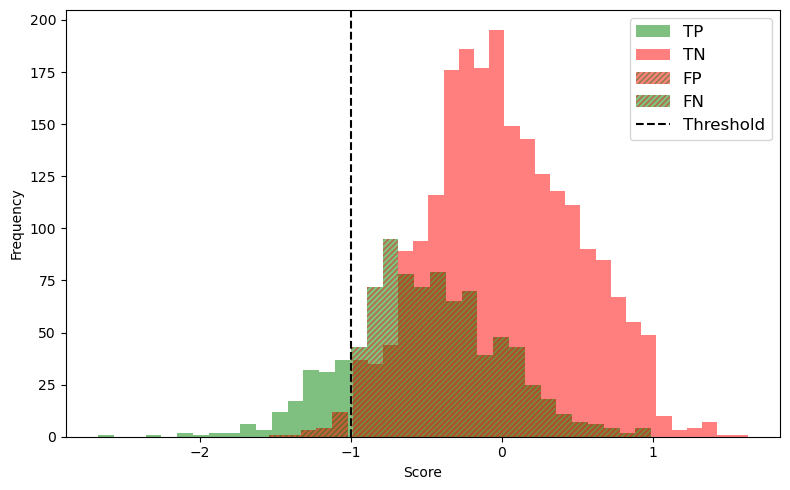

nan
0      -1.164520
1       0.454040
2      -1.246540
3      -1.227790
4      -1.200360
          ...   
3110    0.064841
3111   -1.375220
3112    0.403522
3115    0.380346
3116    0.092424
Name: qsar_pred, Length: 928, dtype: float64


: 

In [15]:
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson
from scipy.stats import gaussian_kde


def num_from_width(data, binwidth=0.1):
    data_range = np.max(data)-np.min(data)
    num_bins = int(data_range/binwidth)

    return num_bins


# Could either transform in the same way or also produce this for our model

for pred_software_id, predicted_values in enumerate(predictions): 

    class_pred = np.where(predicted_values>-1, 0,1)

    class0 = predicted_values[class_true ==0] # (BBB penetrant)
    class1 = predicted_values[class_true ==1] # (BBB non-penetrant)

    print(sum(class0))
    print(class1)

    plt.figure(figsize=(8, 5))

    x = np.linspace(0, 6, 500)
    
    threshold = -1

    plt.hist(class1[class1 < threshold], bins=num_from_width(class1[class1 < threshold]), density=False, alpha=0.5,
            color='green', label='TP')
    plt.hist(class0[class0 >= threshold], bins=num_from_width(class0[class0 >= threshold]), density=False, alpha=0.5,
            color='red', label='TN')
    plt.hist(class0[class0 < threshold], bins=num_from_width(class0[class0 < threshold]), density=False, alpha=0.5,
            facecolor='red', hatch='//////', edgecolor='green', linewidth=0.0, label='FP')
    plt.hist(class1[class1 >= threshold], bins=num_from_width(class1[class1 >= threshold]), density=False, alpha=0.5,
            facecolor='green', hatch='//////', edgecolor='red', linewidth=0.0, label='FN')


    

    plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
    plt.xlabel('Score')
    plt.ylabel('Frequency')
    plt.legend(fontsize=12)                        
    plt.tight_layout()

    # plt.savefig(f'../model_evaluation/{ds}/historgram_tptnfpfn_{SEED}_{ds}.png', dpi=300)
    plt.show()

In [ ]:
# 